# Identifiability / null-space analysis of the CT-SH decomposition

Take one 512x512 view, decompose it **downsampled x32 -> 16x16** (so the full Jacobian is
tiny and every eigenvector is a picture), then read the local geometry of the objective
at the converged state:

1. **Decompose** the 16x16 view (this is an inverse crime -- `ct_sh`-rendered, Fresnel-ON --
   so the residual floor is only the GT-map quantization).
2. **Gauss-Newton spectrum.** Build `J` (residual Jacobian) at the final state and
   eigendecompose `J^T J`. Small eigenvalues = combinations of parameter updates the data
   cannot see -- the flat directions that stall the optimizer.
3. **Project the flat directions back** into albedo / metallic / roughness maps + an
   SH-x-image array, to *see* which coordinated moves cancel out.
4. **Per-pixel residual map** (where the fit stays bad) and **per-pixel participation** in
   the null modes (which pixels do the cancelling).

### Three things this notebook is careful about

* **Natural parameter space, not raw.** The optimizer works in `sigmoid(raw)` coordinates; a
  saturated sigmoid (metallic ~ 0) makes the *raw* columns of `J` vanish for a
  parameterization reason, not a data one. We build `J` in **value space** (actual
  albedo/metallic/roughness), which is also what we want to visualize.
* **`J^T J` is the Gauss-Newton Hessian** (it drops `sum r_i grad^2 r_i`). That is a valid
  approximation of the true Hessian **only near a good fit** -- which the inverse crime
  gives us. Away from the solution, read it as identifiability, not curvature.
* **`eig(J^T J)` squares the condition number**, so the *smallest* eigenvalues (the ones we
  care about) are the least trustworthy. Everything is fp64 and the `~1e-16 * lambda_max`
  noise floor is drawn on the spectrum. An optional cell cross-checks with `svd(J)`.

> "Gradient w.r.t. the input pixels": the observations are constants and
> `d(0.5||r||^2)/d(y_obs) = -r`, so that map *is* the residual map (section 4).


In [1]:
import sys, os, json, math, time
from pathlib import Path
import numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

REPO = Path('.').resolve()
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
os.environ.setdefault('WANDB_MODE', 'disabled')

from idr.config import DEFAULT_CFG
from idr.data.geometry import make_proxy_geometry
from idr.data.scene_io import load_scene
from idr.optim.models.ct_sh import _optimize_ct_sh
from idr.render import shade_ct_sh
from idr.render.brdf import _get_ggx_sh_lut

# ── config ────────────────────────────────────────────────────────────────────
SCENE      = Path('results/3dfront-batch/datasets/1f19c3ef_v2/ct-ct_sh-frOn_env')  # <- your 512^2 view
DOWNSAMPLE = 32          # 512 -> 16
N_IMAGES   = 32          # lights used for BOTH the decomposition and the Jacobian
SH_ORDER   = 2
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
N_ITER     = 500          # LM iters (LM is far faster + converges tighter here;
                         # set OPTIMIZER='LBFGS' and N_ITER~400 to compare)
OPTIMIZER  = 'LBFGS'
GT_NPY     = True        # load the lossless float32 GT maps if present (removes the 8-bit floor)

torch.set_grad_enabled(True)
assert SCENE.exists(), f'missing {SCENE}'
print(f'scene: {SCENE}')


c:\Users\felix\miniconda3\envs\torch311\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


scene: results\3dfront-batch\datasets\1f19c3ef_v2\ct-ct_sh-frOn_env


## 1. Load, downsample x32, and decompose

In [2]:
sc = load_scene(SCENE, gt_npy=GT_NPY)
ds = DOWNSAMPLE
def _strd(a): return np.ascontiguousarray(a[::ds, ::ds])
normals_np = _strd(sc['normals_np']); mask_np = _strd(sc['mask_np'])
albedo_gt  = _strd(sc['albedo_np']);  met_gt = _strd(sc['metallic_np']); rou_gt = _strd(sc['roughness_np'])
images     = [_strd(im) for im in sc['images'][:N_IMAGES]]
sh_gt      = sc.get('sh_coeffs')
sh_gt      = None if sh_gt is None else [np.asarray(s, np.float32) for s in sh_gt[:N_IMAGES]]
H, W = normals_np.shape[:2]
M = int(mask_np.sum())
K = len(images)
DT = torch.float64
print(f'downsampled to {H}x{W}, masked px M={M}, images K={K}')

normals_hw, frag_hw, mask_hw, cam_pos = make_proxy_geometry(
    normals_np, mask_np, fov_deg=60.0, cam_dist=2.0, device=DEVICE, dtype=DT)

cfg = {**DEFAULT_CFG, 'optimizer': OPTIMIZER, 'n_iter': N_ITER, 'lbfgs_max_iter': 40,
       'lm_linear_solver': 'auto', 'lm_structured': True,
       'log_every': max(1, N_ITER // 5), 'loss': 'L2', 'sh_order': SH_ORDER, 'double': True,
       'tr_albedo': 'sigmoid', 'tr_metallic': 'sigmoid', 'tr_roughness': 'sigmoid',
       'init_roughness_zero': True,
       'lambda_tv': 0.0, 'lambda_sparse': 0.0, 'lambda_white': 0.0,
       'lambda_metallic_l1': 0.0, 'lambda_metallic_binarize': 0.0}   # NO regularizers: study the
                                                                     # data term's geometry alone

t0 = time.perf_counter()
albedo_out, sh_out, met_out, rou_out, shadings, history, _ = _optimize_ct_sh(
    images, normals_hw, frag_hw, mask_hw, cam_pos, met_gt, rou_gt, cfg,
    gt_sh_coeffs=sh_gt, gt_albedo=albedo_gt)
print(f'decomposed in {time.perf_counter()-t0:.1f}s   final data-loss={history[-1]:.3e}')


downsampled to 16x16, masked px M=256, images K=32
  [init]          loss=1.414e-01  data=1.414e-01  metallic=0.500  roughness=0.100
  [   0]    1.1s  loss=6.122e-04  data=6.122e-04  metallic=0.514  roughness=0.100
  [ 100]   97.5s  loss=9.326e-07  data=9.326e-07  metallic=0.030  roughness=0.409
  [ 200]  205.7s  loss=6.608e-07  data=6.608e-07  metallic=0.029  roughness=0.419
  [ 300]  305.2s  loss=6.583e-07  data=6.583e-07  metallic=0.029  roughness=0.419
  [ 400]  412.7s  loss=6.564e-07  data=6.564e-07  metallic=0.029  roughness=0.419


KeyboardInterrupt: 

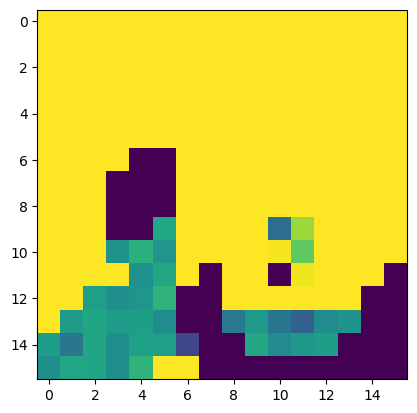

In [3]:
plt.imshow(rou_gt)

## 2. Build `J` at the converged state and eigendecompose `J^T J`

`J` is built in **natural (value) space** for the masked pixels: parameters are
`albedo (M,3)`, `metallic (M,1)`, `roughness (M,1)`, and `sh (K, n_sh, 3)`. The residual is
`(render - observed)` over all masked pixels and images, so `J^T J` (P x P) is the
Gauss-Newton Hessian of the data term. Everything is fp64 and accumulated one image at a
time (each image's residual only touches its own SH block).

In [4]:
lut = _get_ggx_sh_lut(DEVICE, n_bands=SH_ORDER + 1).to(DT)
flat_mask = mask_hw.reshape(-1)
N_m  = normals_hw.reshape(-1, 3)[flat_mask]
view_m = torch.nn.functional.normalize(cam_pos[None] - frag_hw.reshape(-1, 3)[flat_mask], dim=-1)
imgs_m = torch.stack([torch.from_numpy(im).to(DEVICE, DT).reshape(-1, 3)[flat_mask]
                      for im in images])                       # (K, M, 3)
n_sh = (SH_ORDER + 1) ** 2

# converged natural-space parameters (masked)
ab0 = torch.from_numpy(albedo_out).to(DEVICE, DT).reshape(-1, 3)[flat_mask].clone()   # (M,3)
me0 = torch.from_numpy(met_out).to(DEVICE, DT).reshape(-1, 1)[flat_mask].clone()      # (M,1)
ro0 = torch.from_numpy(rou_out).to(DEVICE, DT).reshape(-1, 1)[flat_mask].clone()      # (M,1)
sh0 = torch.from_numpy(sh_out).to(DEVICE, DT).clone()                                 # (K,n_sh,3)

# parameter layout in the flat vector theta
OFF = {'albedo': 0, 'metallic': 3 * M, 'roughness': 4 * M, 'sh': 5 * M}
P = 5 * M + K * n_sh * 3
INV_SQRT_N = 1.0 / math.sqrt(K * M * 3)          # residual scale (uniform -> eigvecs unchanged)

def _split(theta):
    ab = theta[OFF['albedo']:OFF['metallic']].view(M, 3)
    me = theta[OFF['metallic']:OFF['roughness']].view(M, 1)
    ro = theta[OFF['roughness']:OFF['sh']].view(M, 1)
    sh = theta[OFF['sh']:].view(K, n_sh, 3)
    return ab, me, ro, sh

def _resid_k(theta, k):
    ab, me, ro, sh = _split(theta)
    return (shade_ct_sh(view_m, N_m, ab, sh[k], me, ro, lut=lut,
                        diffuse_fresnel=True) - imgs_m[k]).reshape(-1) * INV_SQRT_N

theta0 = torch.cat([ab0.reshape(-1), me0.reshape(-1), ro0.reshape(-1), sh0.reshape(-1)])
print(f'P = {P} parameters  (albedo {3*M} + metallic {M} + roughness {M} + sh {K*n_sh*3})')

JtJ = torch.zeros(P, P, device=DEVICE, dtype=DT)
Jtr = torch.zeros(P, device=DEVICE, dtype=DT)
loss = 0.0
from torch.func import jacrev
for k in range(K):
    Jk = jacrev(lambda th, _k=k: _resid_k(th, _k))(theta0)     # (M*3, P)
    with torch.no_grad():
        rk = _resid_k(theta0, k)
        JtJ += Jk.T @ Jk
        Jtr += Jk.T @ rk
        loss += float(rk.pow(2).sum())
    del Jk
JtJ = 0.5 * (JtJ + JtJ.T)                                       # symmetrize away fp noise
print(f'sum r^2 at theta0 = {loss:.3e}   ||grad|| = {Jtr.norm():.3e}')

evals, evecs = torch.linalg.eigh(JtJ)                           # ascending
evals = evals.clamp_min(0)                                      # tiny negatives are fp noise
lam_max = float(evals[-1])
floor = 1e-16 * lam_max                                         # eig(JtJ) trust floor (fp64)
print(f'lambda_max={lam_max:.3e}  lambda_min={float(evals[0]):.3e}  '
      f'cond={lam_max/max(float(evals[0]),1e-300):.2e}')
print(f'effective rank (lambda > 1e-16*lambda_max): {int((evals > floor).sum())} / {P}')


P = 2144 parameters  (albedo 768 + metallic 256 + roughness 256 + sh 864)
sum r^2 at theta0 = 5.503e-06   ||grad|| = 1.254e-05
lambda_max=6.088e-01  lambda_min=2.902e-16  cond=2.10e+15
effective rank (lambda > 1e-16*lambda_max): 2144 / 2144


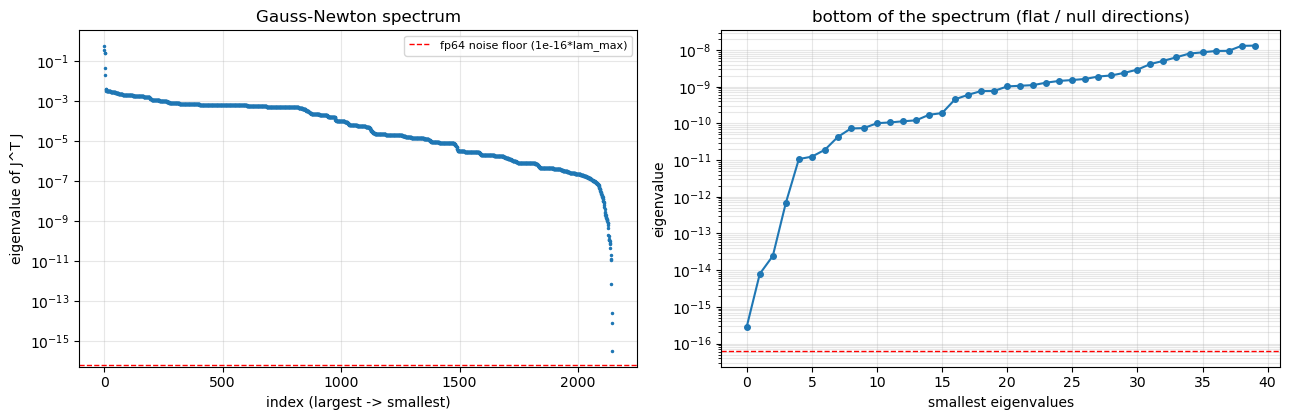

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
idx = np.arange(P)
ax[0].semilogy(idx, evals.cpu().numpy()[::-1] + 1e-300, '.', ms=3)
ax[0].axhline(floor, color='r', ls='--', lw=1, label='fp64 noise floor (1e-16*lam_max)')
ax[0].set_xlabel('index (largest -> smallest)'); ax[0].set_ylabel('eigenvalue of J^T J')
ax[0].set_title('Gauss-Newton spectrum'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3, which='both')

# zoom on the bottom of the spectrum: the flat directions
nb = min(40, P)
ax[1].semilogy(np.arange(nb), evals.cpu().numpy()[:nb] + 1e-300, 'o-', ms=4)
ax[1].axhline(floor, color='r', ls='--', lw=1)
ax[1].set_xlabel('smallest eigenvalues'); ax[1].set_ylabel('eigenvalue')
ax[1].set_title('bottom of the spectrum (flat / null directions)'); ax[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## 3. Project the flat directions back to maps

Each eigenvector `v` is a P-vector; split it into an albedo map, a metallic map, a roughness
map and an SH-x-image block. The **smallest**-eigenvalue eigenvectors are the flat
directions -- the coordinated perturbations that leave the images (nearly) unchanged. The
per-image SH panel shows whether the mode is *global* (all images move together, e.g. the
albedo<->lighting scale mode) or *local*.

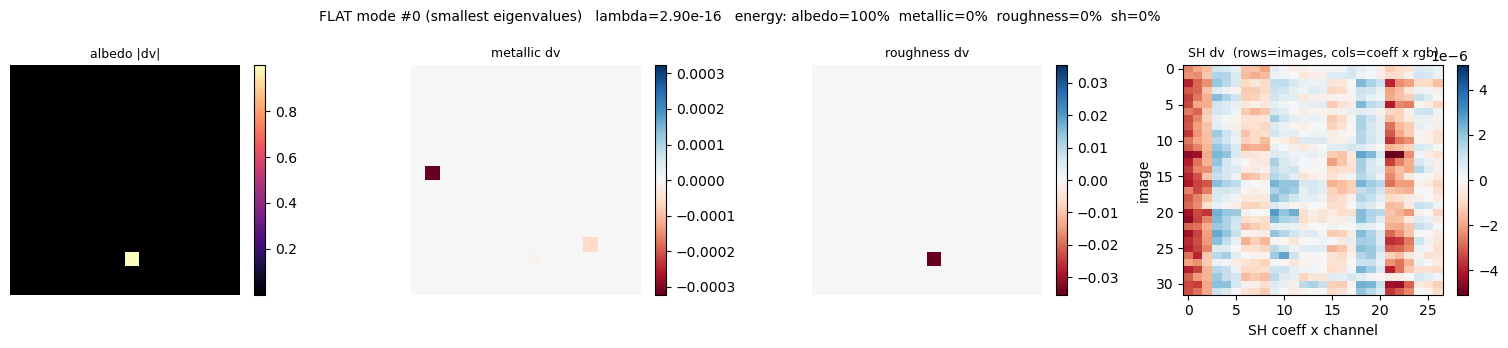

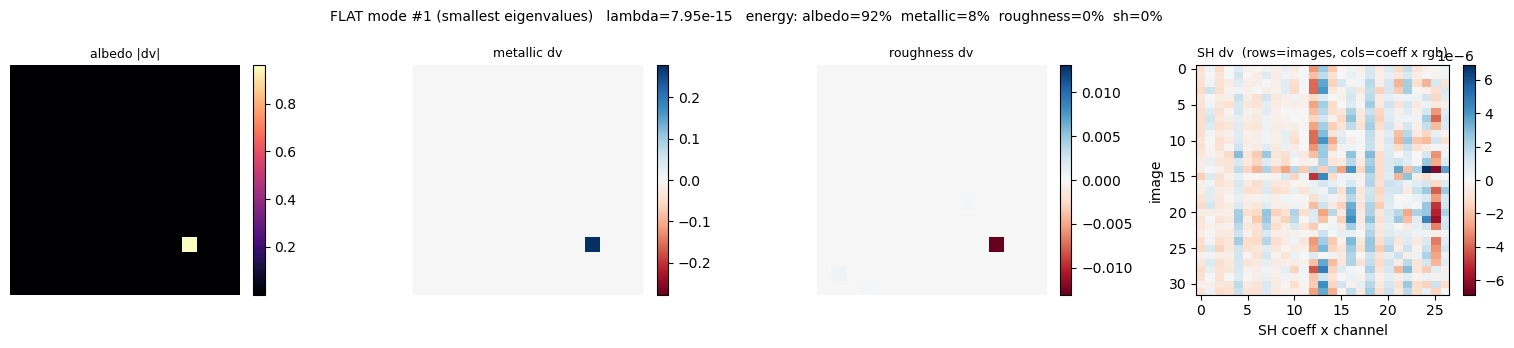

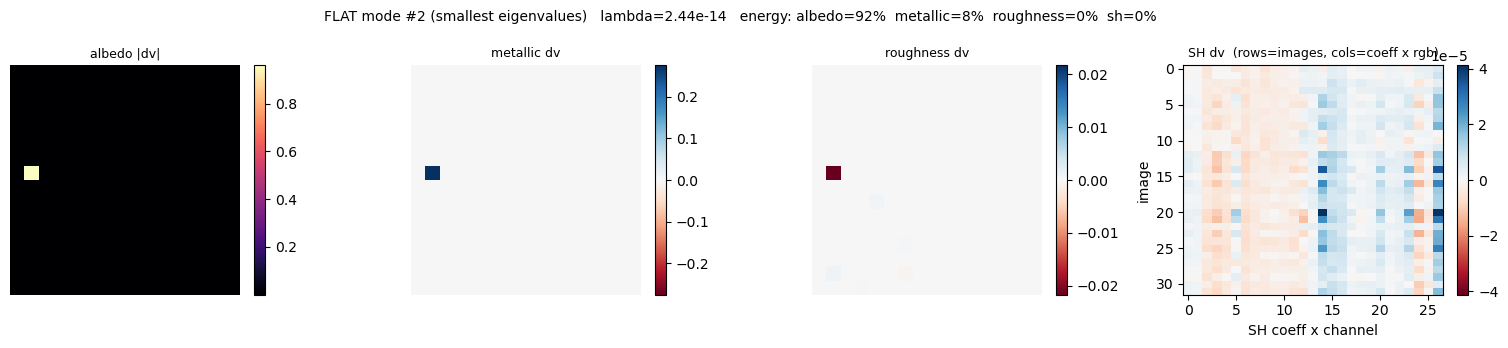

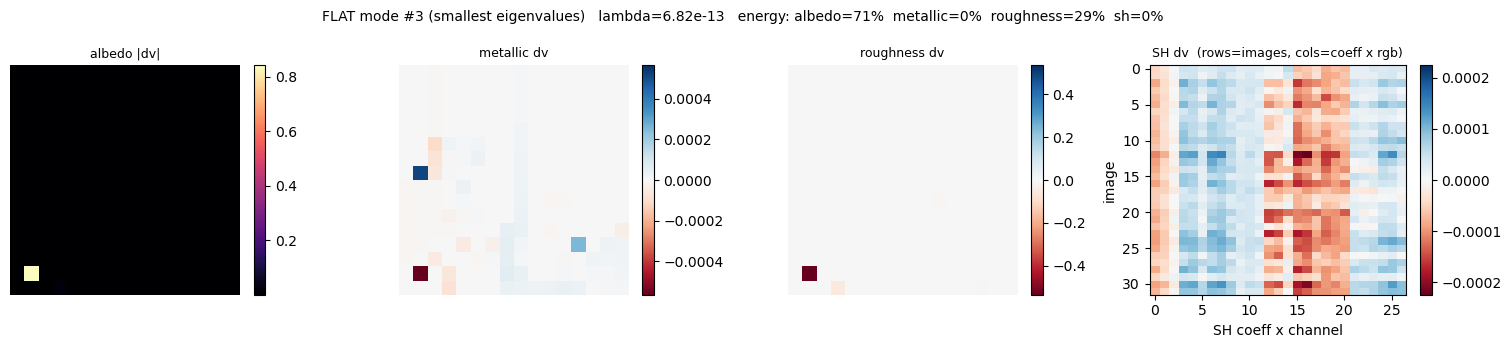

for contrast, the single STIFFEST (largest-eigenvalue) direction:


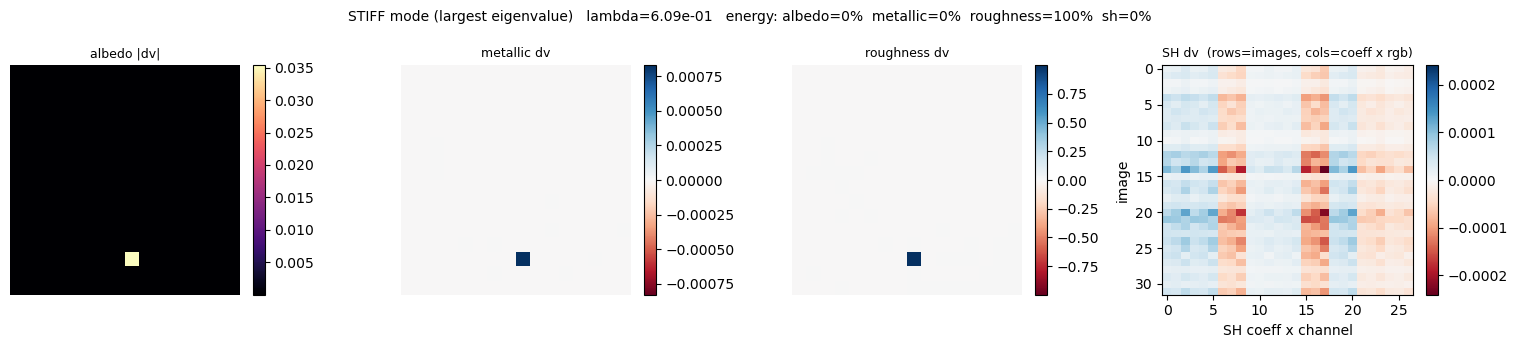

In [6]:
def scatter_map(vec_m, ch=1):
    """(M,) or (M,ch) masked vector -> (H,W[,ch]) image with NaN background."""
    v = np.asarray(vec_m, np.float64).reshape(M, -1)
    out = np.full((H * W, v.shape[1]), np.nan)
    out[flat_mask.cpu().numpy()] = v
    out = out.reshape(H, W, v.shape[1])
    return out[..., 0] if ch == 1 else out

def show_mode(j, title):
    v = evecs[:, j].cpu().numpy()
    ab = v[OFF['albedo']:OFF['metallic']].reshape(M, 3)
    me = v[OFF['metallic']:OFF['roughness']].reshape(M)
    ro = v[OFF['roughness']:OFF['sh']].reshape(M)
    sh = v[OFF['sh']:].reshape(K, n_sh * 3)
    # energy fraction each parameter group carries in this eigenvector
    frac = {g: float((v[OFF[g]:nxt] ** 2).sum())
            for g, nxt in (('albedo', OFF['metallic']), ('metallic', OFF['roughness']),
                           ('roughness', OFF['sh']), ('sh', P))}
    panels = [('albedo |dv|', scatter_map(np.linalg.norm(ab, axis=1)), 'magma'),
              ('metallic dv', scatter_map(me), 'RdBu'),
              ('roughness dv', scatter_map(ro), 'RdBu')]
    fig, axs = plt.subplots(1, 4, figsize=(15.5, 3.5))
    for a, (t, im, cm) in zip(axs, panels):
        if cm == 'RdBu':
            m = np.nanmax(np.abs(im)) or 1.0
            h = a.imshow(im, cmap=cm, norm=TwoSlopeNorm(0, -m, m))
        else:
            h = a.imshow(im, cmap=cm)
        a.set_title(t, fontsize=9); a.axis('off'); plt.colorbar(h, ax=a, fraction=0.046)
    hm = axs[3].imshow(sh, aspect='auto', cmap='RdBu',
                       norm=TwoSlopeNorm(0, -(np.abs(sh).max() or 1), (np.abs(sh).max() or 1)))
    axs[3].set_title('SH dv  (rows=images, cols=coeff x rgb)', fontsize=9)
    axs[3].set_xlabel('SH coeff x channel'); axs[3].set_ylabel('image')
    plt.colorbar(hm, ax=axs[3], fraction=0.046)
    fig.suptitle(f'{title}   lambda={float(evals[j]):.2e}   '
                 f'energy: ' + '  '.join(f'{g}={frac[g]:.0%}' for g in frac), fontsize=10)
    plt.tight_layout(); plt.show()

N_FLAT = 4
for j in range(N_FLAT):
    show_mode(j, f'FLAT mode #{j} (smallest eigenvalues)')
print('for contrast, the single STIFFEST (largest-eigenvalue) direction:')
show_mode(P - 1, 'STIFF mode (largest eigenvalue)')


## 4. Residual map, and which pixels do the cancelling

Left: **per-pixel residual RMS** over images -- this is the "loss per pixel" and, since the
observations are constants, also `|d loss / d observation|`. Right: **per-pixel participation
in the flat directions** -- the summed magnitude of the bottom-`N_FLAT` eigenvectors'
albedo/metallic/roughness components at each pixel. Bright pixels there are the ones whose
parameter updates cancel out.

In [7]:
# N_FLAT = 20

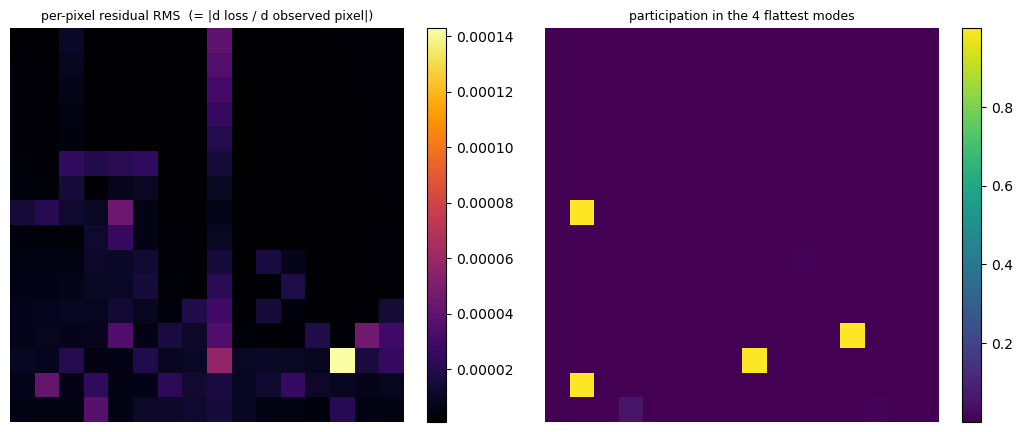

per-group self-sensitivity (mean diagonal of J^T J):
  albedo     mean=6.064e-04  median=6.031e-04
  metallic   mean=1.186e-03  median=1.189e-03
  roughness  mean=6.099e-03  median=5.224e-06
  sh         mean=1.455e-04  median=8.048e-05

A small roughness/metallic self-sensitivity means the parameter is individually weakly seen -- which shows up as flat modes dominated by that group.


In [8]:
with torch.no_grad():
    rr = torch.stack([_resid_k(theta0, k).view(M, 3) for k in range(K)])   # (K,M,3)
    resid_rms = rr.pow(2).mean(dim=(0, 2)).sqrt().cpu().numpy()            # (M,)

part = np.zeros(M)
for j in range(N_FLAT):
    v = evecs[:, j].cpu().numpy()
    ab = v[OFF['albedo']:OFF['metallic']].reshape(M, 3)
    me = v[OFF['metallic']:OFF['roughness']].reshape(M)
    ro = v[OFF['roughness']:OFF['sh']].reshape(M)
    part += np.linalg.norm(np.concatenate([ab, me[:, None], ro[:, None]], 1), axis=1) ** 2
part = np.sqrt(part)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.4))
h0 = ax[0].imshow(scatter_map(resid_rms), cmap='inferno')
ax[0].set_title('per-pixel residual RMS  (= |d loss / d observed pixel|)', fontsize=9)
ax[0].axis('off'); plt.colorbar(h0, ax=ax[0], fraction=0.046)
h1 = ax[1].imshow(scatter_map(part), cmap='viridis')
ax[1].set_title(f'participation in the {N_FLAT} flattest modes', fontsize=9)
ax[1].axis('off'); plt.colorbar(h1, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

# per-parameter-group sensitivity: the diagonal of J^T J, aggregated. Distinguishes a
# genuinely entangled direction from a parameter that is just individually insensitive.
diag = torch.diagonal(JtJ).cpu().numpy()
groups = {'albedo': diag[OFF['albedo']:OFF['metallic']], 'metallic': diag[OFF['metallic']:OFF['roughness']],
          'roughness': diag[OFF['roughness']:OFF['sh']], 'sh': diag[OFF['sh']:]}
print('per-group self-sensitivity (mean diagonal of J^T J):')
for g, d in groups.items():
    print(f'  {g:10s} mean={d.mean():.3e}  median={np.median(d):.3e}')
print('\nA small roughness/metallic self-sensitivity means the parameter is individually '
      'weakly seen -- which shows up as flat modes dominated by that group.')


## 4b. Is the stall fundamental or algorithmic? (works for ANY optimizer)

The right question is not "where is the gradient" -- since `g = J^T r` is intrinsically
`sqrt(lambda)`-weighted, the gradient energy is *always* ~100% in the stiff directions and
tells you nothing. The right question is **how much of the residual a Gauss-Newton step could
still remove.** Writing the residual in the left-singular basis, direction `i` explains
`(u_i^T r)^2 = c_i^2 / lambda_i` of the residual variance (`c_i = v_i^T g`). So:

* **reducible via well-conditioned directions** (`lambda` not tiny) = safe descent the
  optimizer *left on the table* -> an **algorithmic** stall (line-search failure, too-small
  L-BFGS memory, bad scaling): keep going / raise the memory / switch to LM.
* **near-zero reducible residual** = you are at a stationary point; whatever error remains is
  the model/quantization floor or is reachable only through the flat subspace (unreliable
  huge steps) -> a **fundamental** limit; consult sections 3-5 for identifiability.

This is exactly the number to compare across optimizers: rerun section 1 with
`OPTIMIZER='LBFGS'` (or fewer iters) and read this cell. LM's damping refuses flat-direction
steps, so at convergence LM parks with ~0 reducible residual; a large reducible residual at
an L-BFGS endpoint means L-BFGS quit early, not that the problem is degenerate.

sqrt(sum r^2) = 2.346e-03   ||grad|| = 1.254e-05
residual reducible by a Gauss-Newton step (all trustworthy dirs): 78.3% of the residual

       stiffness threshold   reducible residual
  lambda > 1e-04*lam_max                    4.1%
  lambda > 1e-06*lam_max                   53.7%
  lambda > 1e-08*lam_max                   77.6%

VERDICT:
  54% of the residual is removable via WELL-conditioned directions ->
  the optimizer stopped before exhausting cheap descent: ALGORITHMIC stall.
  Fix: more iters, larger L-BFGS history, better scaling, or LM (takes those steps).


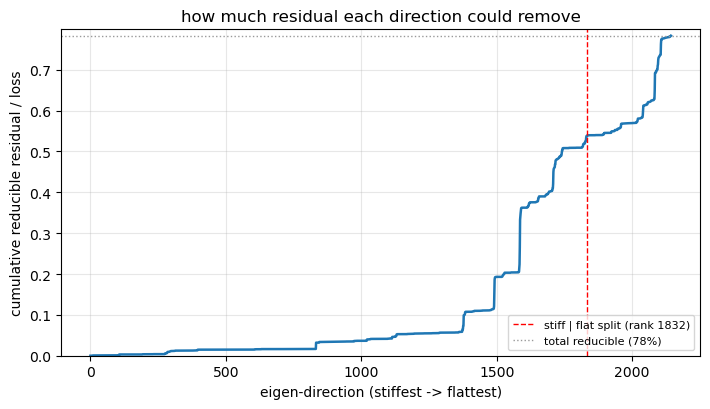

Curve rising mostly LEFT of the split line -> reducible via stiff dirs (algorithmic); rising only in the flat tail -> ill-conditioned; staying near 0 -> converged.


In [9]:
g = Jtr                                     # = J^T r, the endpoint gradient
c2 = ((evecs.T @ g) ** 2).cpu().numpy()     # gradient^2 per eigenvector (ascending eval)
ev = evals.cpu().numpy()

# (u_i^T r)^2 = c_i^2 / lambda_i : residual variance direction i can remove. Trust only
# eigenvalues above the fp noise floor (below it, c/ev is numerical debris).
trust = ev > floor
red = np.zeros_like(ev)
red[trust] = c2[trust] / ev[trust]
red_total = red.sum()                                     # <= loss, by construction

print(f'sqrt(sum r^2) = {math.sqrt(loss):.3e}   ||grad|| = {math.sqrt(c2.sum()):.3e}')
print(f'residual reducible by a Gauss-Newton step (all trustworthy dirs): '
      f'{red_total/max(loss,1e-300):.1%} of the residual\n')
print(f"{'stiffness threshold':>26} {'reducible residual':>20}")
fracs = {}
for rel in (1e-4, 1e-6, 1e-8):
    w = ev > rel * lam_max
    fracs[rel] = red[w].sum() / max(loss, 1e-300)         # safe-reducible fraction
    print(f"  lambda > {rel:.0e}*lam_max      {fracs[rel]:18.1%}")

frac_well = fracs[1e-6]                                    # safe (well-conditioned) descent
frac_all  = red_total / max(loss, 1e-300)                 # incl. near-flat (unreliable) dirs
print('\nVERDICT:')
if frac_well > 0.10:
    print(f'  {frac_well:.0%} of the residual is removable via WELL-conditioned directions ->')
    print('  the optimizer stopped before exhausting cheap descent: ALGORITHMIC stall.')
    print('  Fix: more iters, larger L-BFGS history, better scaling, or LM (takes those steps).')
elif frac_all - frac_well > 0.10:
    print(f'  only {frac_well:.0%} removable via well-conditioned dirs, but {frac_all:.0%} incl. '
          f'near-flat ones ->')
    print('  you are in an ILL-CONDITIONED valley: cheap descent is exhausted, further progress')
    print('  needs damped 2nd-order steps (LM) and is near the identifiability limit.')
else:
    print(f'  only {frac_all:.0%} of the residual is reducible at all -> STATIONARY point reached.')
    print('  The remaining error is the model/quantization floor or lives in the null subspace;')
    print('  no optimizer resolves it -- see sections 3-5 for which intrinsics are unidentifiable.')

fig, ax = plt.subplots(figsize=(7.2, 4.2))
cum = np.cumsum(red[::-1]) / max(loss, 1e-300)            # stiffest -> flattest
ax.plot(np.arange(P), cum, lw=1.8)
kcross = int((ev > 1e-6 * lam_max).sum())
ax.axvline(kcross, color='r', ls='--', lw=1, label=f'stiff | flat split (rank {kcross})')
ax.axhline(frac_all, color='0.6', ls=':', lw=1, label=f'total reducible ({frac_all:.0%})')
ax.set_xlabel('eigen-direction (stiffest -> flattest)')
ax.set_ylabel('cumulative reducible residual / loss')
ax.set_title('how much residual each direction could remove'); ax.set_ylim(0, max(1.02*frac_all, 0.02))
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Curve rising mostly LEFT of the split line -> reducible via stiff dirs (algorithmic); '
      'rising only in the flat tail -> ill-conditioned; staying near 0 -> converged.')


## 5. Validate the machinery: the analytic albedo<->lighting scale mode

The diffuse term is `~ albedo * irradiance(sh)`, so scaling every albedo up and every SH
coefficient down by the same factor barely changes the render (only the weak specular term
breaks it). That direction -- `+albedo, -sh, 0 elsewhere` -- should have a tiny Rayleigh
quotient `v^T J^T J v / v^T v`. If it does, the eigen-analysis is finding real ambiguities,
not numerical debris.

In [10]:
v = torch.zeros(P, device=DEVICE, dtype=DT)
v[OFF['albedo']:OFF['metallic']] =  ab0.reshape(-1)      # +albedo (its own values)
v[OFF['sh']:]                    = -sh0.reshape(-1)      # -sh
v = v / v.norm()
rq = float((v @ (JtJ @ v)))
print(f'Rayleigh quotient of the +albedo/-SH scale direction: {rq:.3e}')
print(f'  vs lambda_max = {lam_max:.3e}   ratio = {rq/lam_max:.2e}')
print(f'  vs lambda_min = {float(evals[0]):.3e}')
# where does this analytic mode sit in the spectrum? (roughness modes are flatter still)
n_flatter = int((evals < rq).sum())
proj = (evecs.T @ v).cpu().numpy() ** 2          # energy of v per eigenvector (ascending eval)
cum = np.cumsum(proj)
k50 = int(np.searchsorted(cum, 0.5)); k90 = int(np.searchsorted(cum, 0.9))
print(f'  eigen-directions flatter than this scale mode: {n_flatter} / {P}')
print(f'  50% / 90% of the scale direction lies in the {k50} / {k90} flattest eigenvectors')
print('\nInterpretation: ratio << 1 confirms the scale mode is (near) null. It is NOT the '
      'single flattest direction -- many per-pixel roughness modes are flatter still '
      '(n_flatter), which is exactly the roughness-unidentifiability story.')


Rayleigh quotient of the +albedo/-SH scale direction: 5.100e-06
  vs lambda_max = 6.088e-01   ratio = 8.38e-06
  vs lambda_min = 2.902e-16
  eigen-directions flatter than this scale mode: 656 / 2144
  50% / 90% of the scale direction lies in the 34 / 78 flattest eigenvectors

Interpretation: ratio << 1 confirms the scale mode is (near) null. It is NOT the single flattest direction -- many per-pixel roughness modes are flatter still (n_flatter), which is exactly the roughness-unidentifiability story.


## 6. Optional: cross-check the tiny eigenvalues with `svd(J)`

`eig(J^T J)` squares the condition number, so the very smallest eigenvalues can be corrupted.
`svd(J)` on the (small, 16^2) dense Jacobian is numerically cleaner: the singular values
squared should match the eigenvalues, and any disagreement at the bottom marks where the
`J^T J` route stopped being trustworthy. Skip if `J` is large.

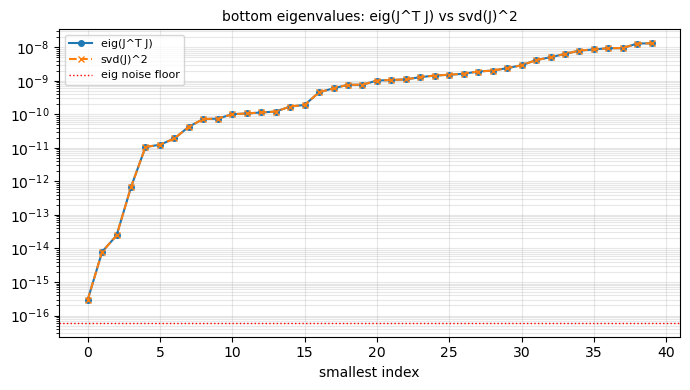

max |eig - svd^2| over the bottom 20: 6.43e-18


In [11]:
if P <= 6000 and K * M * 3 <= 60000:
    rows = []
    for k in range(K):
        rows.append(jacrev(lambda th, _k=k: _resid_k(th, _k))(theta0))
    J = torch.cat(rows, 0)                                  # (K*M*3, P)
    sv = torch.linalg.svdvals(J.double())
    sv2 = (sv ** 2).flip(0)                                 # ascending, comparable to evals
    n = min(len(sv2), len(evals))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(evals.cpu().numpy()[:40] + 1e-300, 'o-', ms=4, label='eig(J^T J)')
    ax.semilogy(sv2.cpu().numpy()[:40] + 1e-300, 'x--', ms=5, label='svd(J)^2')
    ax.axhline(floor, color='r', ls=':', lw=1, label='eig noise floor')
    ax.set_title('bottom eigenvalues: eig(J^T J) vs svd(J)^2', fontsize=10)
    ax.set_xlabel('smallest index'); ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
    plt.tight_layout(); plt.show()
    print(f'max |eig - svd^2| over the bottom 20: '
          f'{float((evals[:20]-sv2[:20]).abs().max()):.2e}')
else:
    print(f'skipped: P={P}, N={K*M*3} too large for a dense svd(J) here.')


## 7. What to read off this

* **Flat modes that mix albedo and SH globally** = the albedo<->lighting **scale ambiguity**
  (section 5). Expected and mostly harmless: the final relight/albedo metrics already fit out
  a global scale. If a flat mode is a *per-image* SH shift with matching albedo, that is a
  per-light exposure ambiguity.
* **Flat modes dominated by roughness (or metallic)** = those maps are **weakly identifiable
  under this lighting**. Cross-check with the per-group self-sensitivity in section 4: if
  roughness's mean diagonal is orders below albedo's, the images barely depend on roughness
  here, so the optimizer has nothing to move it with. This is the local, mechanistic version
  of the batch finding that roughness MAE is uncorrelated with reconstruction error.
* **The residual map** shows *where* error remains; the **participation map** shows *which*
  pixels' updates are wasted (they only move along null directions). Pixels bright in the
  second but dark in the first are well-fit but unconstrained -- moving them changes nothing.
* **Caveats, restated:** value-space `J` (saturation-free); Gauss-Newton (valid near the
  inverse-crime solution); eigenvalues below the drawn floor are noise; and because the
  parameter groups have different natural scales, read cross-group eigenvector energy
  qualitatively -- pair it with the section-4 self-sensitivities.
